In [1]:
import torch

from rl4co.envs import CVRPTWEnv
from rl4co.models.zoo import AttentionModel, AttentionModelPolicy
from rl4co.utils.trainer import RL4COTrainer
from rl4co.utils.ops import batchify

# RL4CO env based on TorchRL
env = CVRPTWEnv(generator_params=dict(num_loc=10)) 

# Policy: neural network, in this case with encoder-decoder architecture
policy = AttentionModelPolicy(env_name=env.name, 
                              embed_dim=128,
                              num_encoder_layers=3,
                              num_heads=8,
                            )

# Model: default is AM with REINFORCE and greedy rollout baseline
model = AttentionModel(env, 
                       baseline="rollout",
                       batch_size = 512,
                       val_batch_size = 64, 
                       test_batch_size = 64, 
                       train_data_size=100_000, # fast training for demo
                       val_data_size=1_000,
                       test_data_size=1_000,
                       optimizer_kwargs={"lr": 1e-4},
                       policy_kwargs={  # we can specify the decode types using the policy_kwargs
                           "train_decode_type": "sampling",
                           "val_decode_type": "greedy",
                           "test_decode_type": "beam_search",
                       }
                       ) 


/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.


In [2]:
trainer = RL4COTrainer(
    max_epochs=3,
    devices=1,
)

trainer.fit(model)
# model = AttentionModel(env, 
#                        baseline="rollout",
#                        batch_size = 512,
#                        val_batch_size = 64, 
#                        test_batch_size = 64, 
#                        train_data_size=100_000, # fast training for demo
#                        val_data_size=1_000,
#                        test_data_size=1_000,
#                        optimizer_kwargs={"lr": 1e-4},
#                        policy_kwargs={  # we can specify the decode types using the policy_kwargs
#                            "train_decode_type": "sampling",
#                            "val_decode_type": "greedy",
#                            "test_decode_type": "beam_search",
#                        }
#                        ).load_from_checkpoint(
#     "05_rl4co_checkpoint.pt",
#     weights_only=False,
#     load_baseline=False,
# )

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [li

┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ env      │ CVRPTWEnv            │      0 │ train │     0 │
│ 1 │ policy   │ AttentionModelPolicy │  694 K │ train │     0 │
│ 2 │ baseline │ WarmupBaseline       │  694 K │ train │     0 │
└───┴──────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 73                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

Output()

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/ut
ilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/tr
ainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/tr
ainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a 
bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to 
improve performance.

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/lo
ops/fit_loop.py:534: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior
during training. If this is intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=3` reached.


In [3]:
# here we evaluate the model on the test set using the beam search decoding strategy as declared in the model constructor
trainer.test(model=model)

val_file not set. Generating dataset instead
test_file not set. Generating dataset instead


Output()

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        test/reward        │    -811.6288452148438     │
└───────────────────────────┴───────────────────────────┘

[{'test/reward': -811.6288452148438}]

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_td_raw = next(iter(model.test_dataloader())).to(device)
td_test = env.reset(test_td_raw)
model = model.to(device)

In [5]:
# Example over full dataset
rewards = []
for batch in model.test_dataloader():
    with torch.inference_mode():
        td = env.reset(batch).to(device)
        out = model(td, decode_type="greedy")
    rewards.append(out["reward"])
print("Average reward over all dataset: %.3f" % torch.cat(rewards).mean().item())

# Example over a single instance
with torch.inference_mode():
    out = model(test_td_raw.clone(), decode_type="greedy")
    print("Average reward: %.3f" % out["reward"].mean().item())

Average reward over all dataset: -880.430
Average reward: -893.191


TensorDict(
    fields={
        action_mask: Tensor(shape=torch.Size([64, 11]), device=cpu, dtype=torch.bool, is_shared=False),
        capacity: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        current_loc: Tensor(shape=torch.Size([64, 2]), device=cpu, dtype=torch.float32, is_shared=False),
        current_node: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        current_time: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        demand: Tensor(shape=torch.Size([64, 10]), device=cpu, dtype=torch.float32, is_shared=False),
        depot: Tensor(shape=torch.Size([64, 2]), device=cpu, dtype=torch.float32, is_shared=False),
        distances: Tensor(shape=torch.Size([64, 11]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        durations: Tensor(shape=torch.Size([64,

<Axes: >

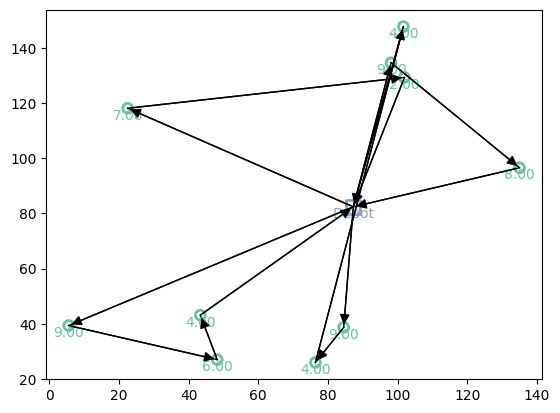

In [6]:
# Example over a single instance
with torch.inference_mode():
    bs = td_test.batch_size[0]
    print(td_test)
    out = model(td_test.clone(), decode_type="multistart_greedy", num_starts=20)
    rewards = torch.stack(out["reward"].split(bs), 1).max(1).values
    print("Average reward: %.3f" % rewards.mean().item())
env.render(test_td_raw, out["actions"].cpu().detach())

# Comparison with ORTools

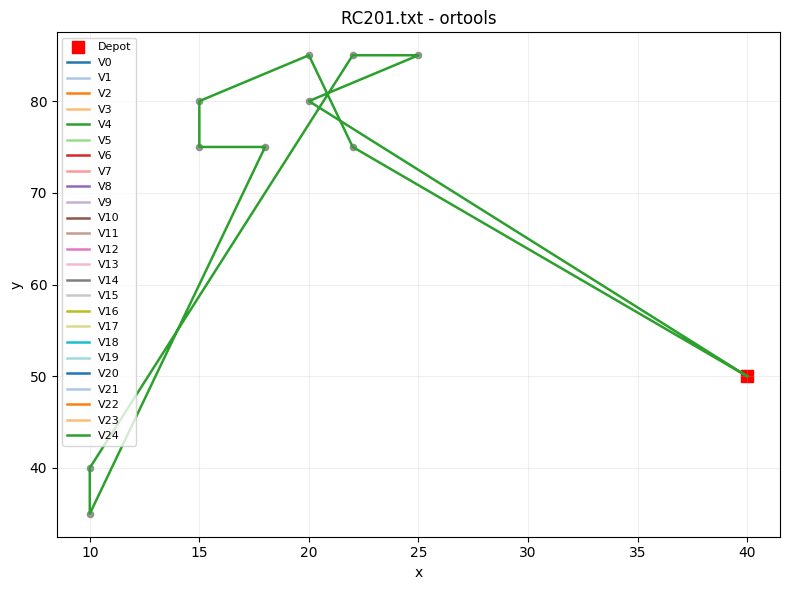

In [11]:
from pathlib import Path

from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.heuristics import ortools_solver
from dvrptw_bench.viz.route_plot import plot_routes


instance = parse_solomon(Path("../dataset/solomon_rc100/RC201.txt"), max_customers=10)
orSolver= ortools_solver.ORToolsVRPTWSolver()

orSol = orSolver.solve(instance, time_limit_s=10)
plot_routes(instance, orSol)


In [8]:
from tensordict import TensorDict
import torch
def _instance_to_td(instance):
    coords = torch.tensor(
        [[instance.depot.x, instance.depot.y], *[[c.x, c.y] for c in instance.customers]],
        dtype=torch.float32,
    )

    demand = torch.tensor([c.demand for c in instance.customers], dtype=torch.float32)
    capacity = float(instance.vehicle_capacity)

    durations = torch.tensor(
        [0.0, *[c.service_time for c in instance.customers]],
        dtype=torch.float32,
    )

    time_windows = torch.tensor(
        [
            [instance.depot.ready_time, instance.depot.due_time],
            *[[c.ready_time, c.due_time] for c in instance.customers],
        ],
        dtype=torch.float32,
    )

    td = TensorDict(
        {
            "depot": coords[0],                  # [2]
            "locs": coords[1:],                  # [N, 2]
            "demand": demand / capacity,         # [N]
            "capacity": torch.tensor([1.0], dtype=torch.float32),  # [1]
            "time_windows": time_windows,        # [N+1, 2]
            "durations": durations,              # [N+1]
        },
        batch_size=[],
    )

    return td.unsqueeze(0)  # batch -> [1, ...]

td_solomon = _instance_to_td(instance)

model = model.to(device).eval()
with torch.inference_mode():
    reset_env = env.reset(td_solomon)
    print(reset_env)
    out = model(reset_env, decode_type="greedy")

rl_distance = -out["reward"].mean().item()  # reward is negative cost

TensorDict(
    fields={
        action_mask: Tensor(shape=torch.Size([1, 11]), device=cpu, dtype=torch.bool, is_shared=False),
        capacity: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        current_loc: Tensor(shape=torch.Size([1, 2]), device=cpu, dtype=torch.float32, is_shared=False),
        current_node: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        current_time: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        demand: Tensor(shape=torch.Size([1, 10]), device=cpu, dtype=torch.float32, is_shared=False),
        depot: Tensor(shape=torch.Size([1, 2]), device=cpu, dtype=torch.float32, is_shared=False),
        distances: Tensor(shape=torch.Size([1, 11]), device=cpu, dtype=torch.float32, is_shared=False),
        done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        durations: Tensor(shape=torch.Size([1, 11]), dev

In [9]:

print("OR-Tools solution: %.3f" % orSol.total_distance)
print("RL solution: %.3f" % rl_distance)

OR-Tools solution: 194.566
RL solution: 214.490


<Axes: >

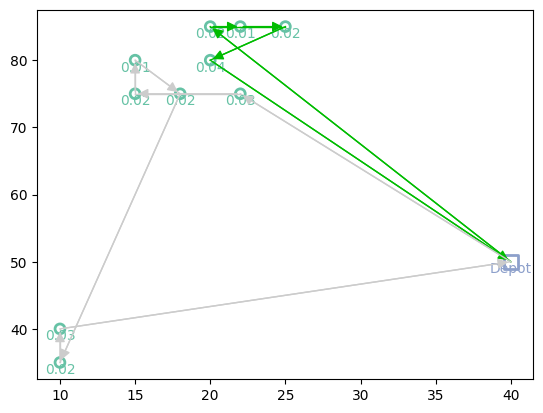

In [10]:
env.render(td_solomon, out["actions"].cpu().detach())